# Multi-agents

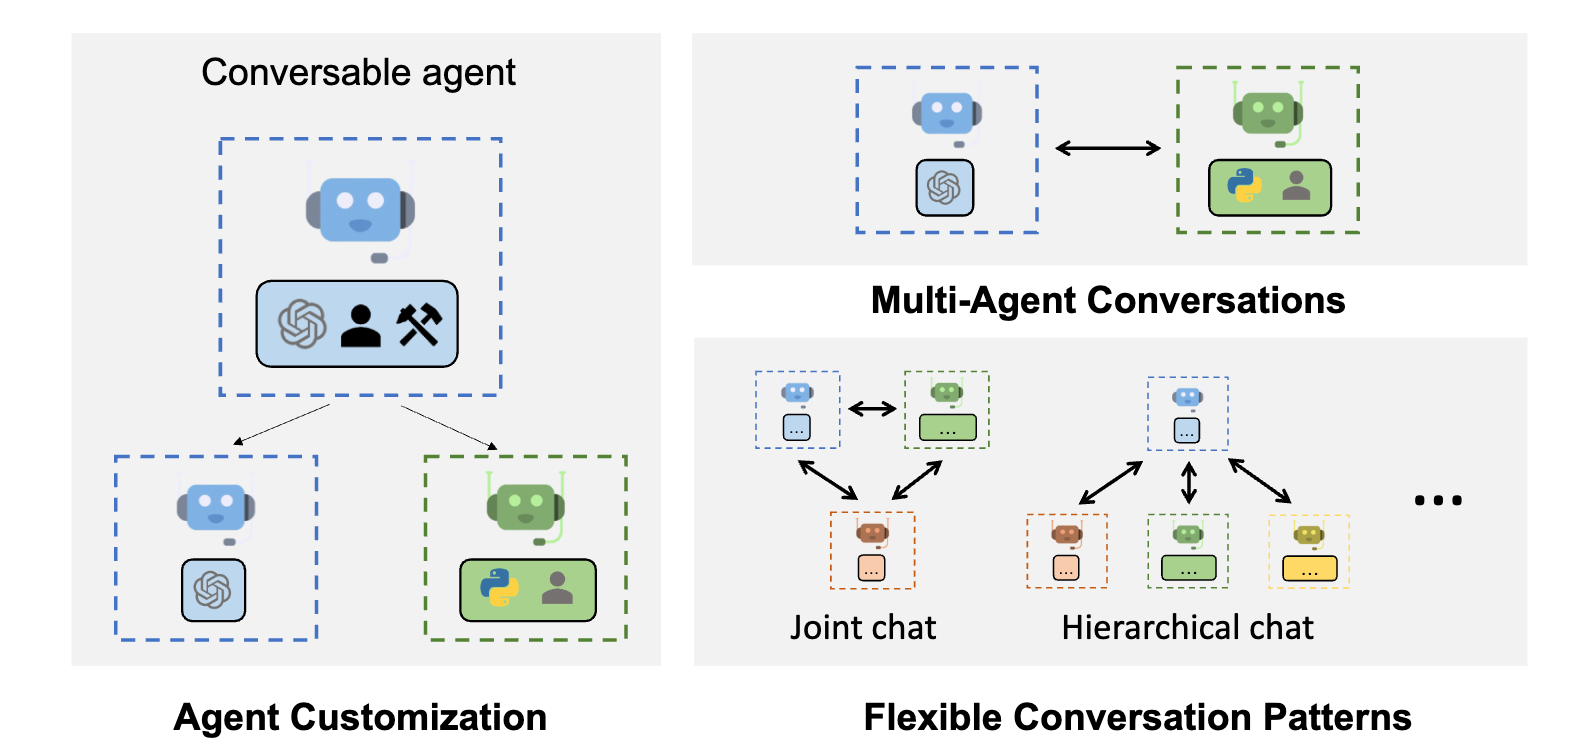



This time, we are going to use several agents that will work together to accomplish a task provided by the user. Let's focus on a simple task for which you might have already used an LLM. Let's ask chatGPT to write a short blogpost about a specific asset. 

## Single agent refinement

We'll first start by using a single agent and ask it to refine its own work. This will work, but it will have some limitations... If we start asking the writer to refine too many aspects of the post, we'll start noticing that it will have a hard time considering them all without forgetting any aspect. 

Let's try this out with a single agent:

In [1]:
# We'll always have to start by creating a llm_config object to configure our agents
llm_config = {
    "model": "gpt-3.5-turbo", 
    }

In [2]:
task = '''
        Write a concise but engaging blogpost about
       udemy.com. Make sure the blogpost is
       within 200 words.
       '''

After defining our task, we can now create a writer agent. This writer agent will also be asked to refine its own work.

In [3]:
import autogen

writer = autogen.AssistantAgent(
    name="Writer",
    system_message="You are a writer. You write engaging and concise " 
        "blogposts (with title) on given topics. You must polish your "
        "writing based on the feedback you receive and give a refined "
        "version. Only return your final work without additional comments.",
    llm_config=llm_config,
)

[autogen.oai.client: 03-22 16:10:41] {150} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.


/Users/jinhohyeon/Desktop/dev/Learned/llm/udemy-aiagents-building-teams-of-llm-agents/.venv/lib/python3.11/site-packages/flaml/__init__.py:20: UserWarning: flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.
  warnings.warn("flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.")


Let's now use the simple `generate_reply()` function to get the single writer agent to work on this task.

In [4]:
reply = writer.generate_reply(messages=[{"content": task, "role": "user"}])
print(reply)

Title: Unleash Your Potential with Udemy

Are you looking to learn a new skill, enhance your career, or pursue a passion? Look no further than Udemy, the ultimate online learning platform! With a wide array of courses ranging from business and technology to personal development and hobbies, Udemy offers something for everyone.

One of the key reasons Udemy stands out is its flexibility. You can learn at your own pace, on your own schedule, making it ideal for busy professionals or eager learners with packed schedules. Plus, the courses are created and taught by experts in their respective fields, ensuring high-quality content and valuable insights.

Whether you want to master digital marketing, improve your photography skills, or dive into data science, Udemy has you covered. With affordable prices and frequent discounts, investing in your personal and professional growth has never been more accessible.

Don't let excuses hold you back from reaching your full potential. Join the millio

And we have our result. Now if we want to refine different aspects and ask a single agent to do so, the writer will have a hard time covering them all... To address this limitation we can use a sequential chat of agents each specialized in refining a different aspect of the blogpost. Let's try it out.

## Two-agents reflection: refinement

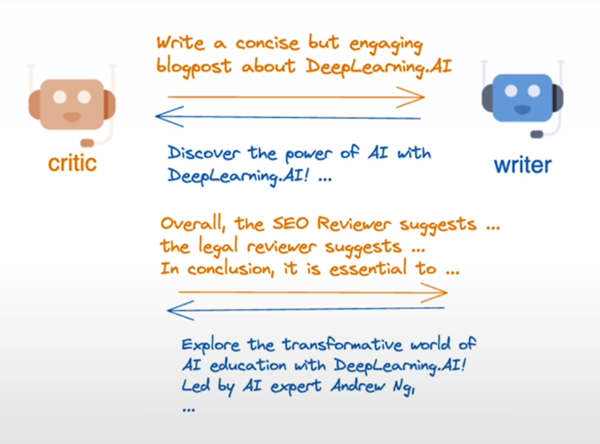

This time we're going to create a chat with two agents:
* The Writer who's going to write the blogpost
* The Critic who's going to reflect on the work of the writer and provide constructive criticism

Since each agent will be focused on a single aspect of the task, this will give us a better result for each aspect, which should yield a task that is better fulfilled. 

The agents will acomplish the same task, so we won't need to update that, but we need to re-define our agents:

In [5]:
writer = autogen.AssistantAgent(
    name="Writer",
    system_message="You are a writer. You write engaging and concise " 
        "blogposts (with title) on given topics. You must polish your "
        "writing based on the feedback you receive from other agents and give a refined "
        "version. Only return your final work without additional comments.",
    llm_config=llm_config,
)

critic = autogen.AssistantAgent(
    name="Critic",
    llm_config=llm_config,
    system_message="You are a critic. You review the work of "
                "the writer and provide constructive "
                "feedback to help improve the quality of the content.",
)

[autogen.oai.client: 03-22 16:10:51] {150} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.


[autogen.oai.client: 03-22 16:10:51] {150} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.




We will initiate the chat by getting the critic to send a message, the task we specified earlier, to the writer. The writer will then answer the critic with a first proposal, the critic will provide constructive criticism, and they will do this for two rounds.

We'll specify that the summary method is the last message, because that should be the last version of refined article. This will allow us to easily pass this result to another app or function that could then publish it or do what we want to do with this blogpost.

In [6]:
chat_result = critic.initiate_chat(
    recipient=writer,
    message=task,
    max_turns=2,
    summary_method="last_msg"
)

Critic (to Writer):


        Write a concise but engaging blogpost about
       udemy.com. Make sure the blogpost is
       within 200 words.
       

--------------------------------------------------------------------------------
Writer (to Critic):

Title: "Unleash Your Potential with Udemy: The Ultimate Online Learning Platform"

Are you looking to expand your knowledge, develop new skills, or even change careers? Look no further than Udemy! With thousands of online courses taught by experts in various fields, Udemy is a treasure trove of learning opportunities waiting to be explored.

Whether you're interested in mastering a programming language, delving into digital marketing, or learning a new hobby like painting or photography, Udemy has a course for you. The platform offers a wide range of courses that are accessible anytime, anywhere, making learning convenient for busy individuals.

One of the best things about Udemy is the flexibility it provides. You can learn at your own

And there we go! We have a refined article!  
We can now explore the last message which is our final version of the blogpost through the summary:

In [7]:
import pprint

pprint.pprint(chat_result.summary)

('Title: "Unlock Your Potential with Udemy: A World of Learning at Your '
 'Fingertips"\n'
 '\n'
 'Are you ready to embark on a journey of self-improvement and knowledge '
 'enhancement? Look no further than Udemy, the leading online learning '
 'platform empowering individuals to upskill and chase their dreams.\n'
 '\n'
 'With over 130,000 courses taught by experts from around the globe, Udemy '
 'offers a diverse range of learning opportunities catering to every interest '
 'and passion. From mastering technical skills like coding and data analytics '
 'to exploring creative pursuits such as music production and graphic design, '
 'Udemy has something for everyone.\n'
 '\n'
 "But don't just take our word for it - with millions of satisfied learners "
 'worldwide, Udemy has transformed lives and careers. Take, for example, '
 'Sarah, a marketing professional who landed her dream job after completing a '
 'digital marketing course on Udemy. Her success story is just one of many '
 "tes